In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
df = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [ ]:
# df[df['Quantity']<0]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

/tmp/ipython-input-159/3737144277.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


In [ ]:
df['IsReturn'] = df['Quantity'] < 0

In [ ]:
df['IsReturn'].value_counts()

,count
IsReturn,
False,531285
True,10624


In [ ]:
sales_df = df[df['Quantity'] > 0]
return_df = df[df['Quantity'] < 0]

In [ ]:
df.dropna(subset = ['Description'],inplace=True)

In [ ]:
# sales_df[sales_df['CustomerID'].isnull()].head(50)
sales_df.loc[1420:1450]


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn
1420,WOODEN BOX OF DOMINOES,24,12/1/2010 14:05,1.25,14911.0,EIRE,30.00,False
1421,TRADITIONAL WOODEN SKIPPING ROPE,12,12/1/2010 14:05,1.25,14911.0,EIRE,15.00,False
1422,BOX OF VINTAGE ALPHABET BLOCKS,6,12/1/2010 14:05,9.95,14911.0,EIRE,59.70,False
1423,CARRIAGE,1,12/1/2010 14:05,50.00,14911.0,EIRE,50.00,False
1424,RED HARMONICA IN BOX,12,12/1/2010 14:05,1.25,14911.0,EIRE,15.00,False
1425,LUNCH BAG SPACEBOY DESIGN,10,12/1/2010 14:11,1.65,16456.0,United Kingdom,16.50,False
1426,LUNCH BAG BLACK SKULL.,10,12/1/2010 14:11,1.65,16456.0,United Kingdom,16.50,False
1427,LUNCH BAG SUKI DESIGN,20,12/1/2010 14:11,1.65,16456.0,United Kingdom,33.00,False
1428,JUMBO BAG PINK POLKADOT,30,12/1/2010 14:11,1.95,16456.0,United Kingdom,58.50,False
1429,JUMBO BAG RED RETROSPOT,40,12/1/2010 14:11,1.95,16456.0,United Kingdom,78.00,False


In [ ]:
sales_df['CustomerID'].isnull().sum()

np.int64(133361)

In [ ]:
sales_df.dropna(how='all', inplace=True)

/tmp/ipython-input-159/2138678978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df.dropna(how='all', inplace=True)


In [ ]:
sales_df['CustomerType'] = np.where(sales_df['CustomerID'].isnull(),"Guest","Registerd")

/tmp/ipython-input-159/3196683511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['CustomerType'] = np.where(sales_df['CustomerID'].isnull(),"Guest","Registerd")


In [ ]:
sales_df[sales_df['CustomerID'].isnull()]

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn,CustomerType
622,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom,0.00,False,Guest
1443,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom,2.51,False,Guest
1444,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom,5.02,False,Guest
1445,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom,3.40,False,Guest
1446,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom,3.32,False,Guest
...,...,...,...,...,...,...,...,...,...
541536,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom,20.65,False,Guest
541537,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom,16.52,False,Guest
541538,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom,4.96,False,Guest
541539,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom,10.79,False,Guest


In [ ]:
sales_df.drop_duplicates(inplace=True)

/tmp/ipython-input-159/4217648514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df.drop_duplicates(inplace=True)


In [ ]:
df

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsReturn
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,False
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,False
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,False
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,False
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,False
...,...,...,...,...,...,...,...,...
541904,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20,False
541905,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60,False
541906,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60,False
541907,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60,False


In [ ]:
#Re-aranging the columns
lst2 = [4,0,1,3,6,2,5,7]
df = df.iloc[:,lst2]

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day
df["DayName"] = df["InvoiceDate"].dt.day_name()

In [ ]:
#Total Revenue
total_revenue = df["TotalPrice"].sum()
total_revenue

np.float64(9747747.933999997)

In [ ]:
#Average Order Value
aov = df.groupby("InvoiceDate")["TotalPrice"].sum().mean()
aov

np.float64(436.9423969698328)

In [ ]:
#monthly revenue
monthly_revenue = df.groupby(["Year", "Month"])["TotalPrice"].sum().reset_index()
monthly_revenue

,Year,Month,TotalPrice
0,2010,12,748957.020
1,2011,1,560000.260
2,2011,2,498062.650
3,2011,3,683267.080
4,2011,4,493207.121
5,2011,5,723333.510
6,2011,6,691123.120
7,2011,7,681300.111
8,2011,8,682680.510
9,2011,9,1019687.622


In [ ]:
# What is RFM?
# RFM = Recency, Frequency, Monetary
# It is used to segment customers based on their purchasing behavior.

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": "max",
    "CustomerID": "count",
    "TotalPrice": "sum"
})


In [ ]:
rfm.columns = ["LastPurchaseDate", "Frequency", "Monetary"]

In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm["Recency"] = (reference_date - rfm["LastPurchaseDate"]).dt.days

In [ ]:
rfm

,LastPurchaseDate,Frequency,Monetary,Recency
CustomerID,,,,
12346.0,2011-01-18 10:17:00,2,0.00,326
12347.0,2011-12-07 15:52:00,182,4310.00,2
12348.0,2011-09-25 13:13:00,31,1797.24,75
12349.0,2011-11-21 09:51:00,73,1757.55,19
12350.0,2011-02-02 16:01:00,17,334.40,310
...,...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60,278
18281.0,2011-06-12 10:53:00,7,80.82,181
18282.0,2011-12-02 11:43:00,13,176.60,8


In [ ]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [ ]:
rfm

,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score
CustomerID,,,,,,,
12346.0,2011-01-18 10:17:00,2,0.00,326,1,1,1
12347.0,2011-12-07 15:52:00,182,4310.00,2,5,5,5
12348.0,2011-09-25 13:13:00,31,1797.24,75,2,3,4
12349.0,2011-11-21 09:51:00,73,1757.55,19,4,4,4
12350.0,2011-02-02 16:01:00,17,334.40,310,1,2,2
...,...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,10,180.60,278,1,1,1
18281.0,2011-06-12 10:53:00,7,80.82,181,1,1,1
18282.0,2011-12-02 11:43:00,13,176.60,8,5,1,1


In [ ]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [ ]:
#customer segmentation
def segment(row):
    if row["RFM_Score"] == "555":
        return "Champions"
    elif row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Loyal Customers"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)

**Kmeans on RFM**

In [ ]:
rfm = rfm[(rfm["Monetary"] > 0)]

In [ ]:
rfm = rfm[["Recency", "Frequency", "Monetary"]]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

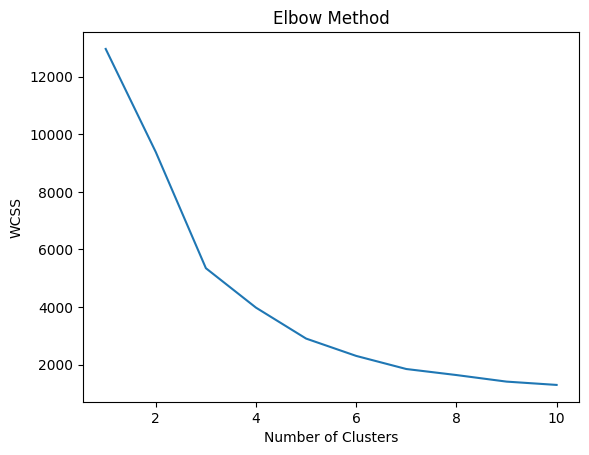

In [ ]:
# finding optimal clusters using elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

/tmp/ipython-input-159/3948348953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)


In [ ]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,2,182,4310.00,1
12348.0,75,31,1797.24,1
12349.0,19,73,1757.55,1
12350.0,310,17,334.40,0
12352.0,36,95,1545.41,1


In [ ]:
#Interpreting Clusters
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,244.153128,28.675070,493.922625
1,39.790741,105.499691,2004.180541
2,1.666667,4821.500000,55039.933333
3,9.000000,1013.400000,192103.854000


In [ ]:
def label_cluster(row):
    if row["Cluster"] == 0:
        return "High Value Customers"
    elif row["Cluster"] == 1:
        return "At Risk"
    elif row["Cluster"] == 2:
        return "Potential Loyalists"
    else:
        return "Low Value"

rfm["Segment"] = rfm.apply(label_cluster, axis=1)

/tmp/ipython-input-159/3323802078.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["Segment"] = rfm.apply(label_cluster, axis=1)


In [ ]:
rfm

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12347.0,2,182,4310.00,1,At Risk
12348.0,75,31,1797.24,1,At Risk
12349.0,19,73,1757.55,1,At Risk
12350.0,310,17,334.40,0,High Value Customers
12352.0,36,95,1545.41,1,At Risk
...,...,...,...,...,...
18280.0,278,10,180.60,0,High Value Customers
18281.0,181,7,80.82,0,High Value Customers
18282.0,8,13,176.60,1,At Risk


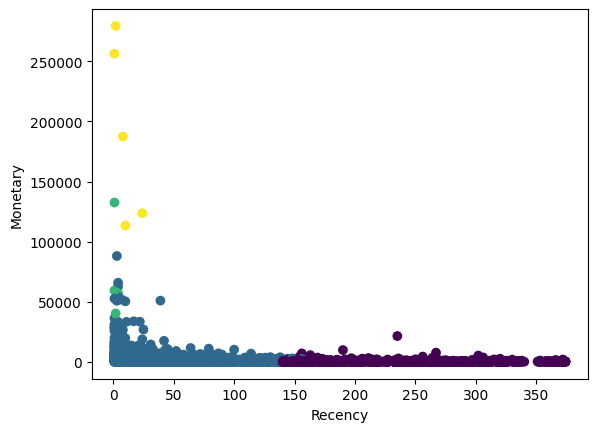

In [ ]:
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

In [ ]:
# Applying KMeans with 4 Clusters
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

/tmp/ipython-input-159/2752189921.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)


In [ ]:
# Evaluate Cluster Quality

from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.601224942129016


In [ ]:
# Understand Clusters
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_summary)


            Recency    Frequency       Monetary
Cluster                                        
0        244.153128    28.675070     493.922625
1         39.790741   105.499691    2004.180541
2          1.666667  4821.500000   55039.933333
3          9.000000  1013.400000  192103.854000


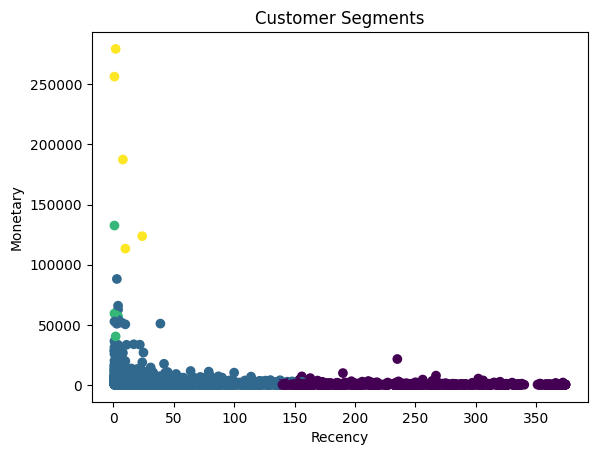

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments")
plt.show()

In [ ]:
#Revenue per cluster
cluster_revenue = rfm.groupby("Cluster")["Monetary"].sum().reset_index()
cluster_revenue.columns = ["Cluster", "Total_Revenue"]

print(cluster_revenue)

   Cluster  Total_Revenue
0        0     528991.131
1        1    6493544.953
2        2     330239.600
3        3     960519.270


In [ ]:
#Revenue contribution percentage
total_revenue = rfm["Monetary"].sum()

cluster_revenue["Revenue_%"] = (
    cluster_revenue["Total_Revenue"] / total_revenue
) * 100

print(cluster_revenue)

   Cluster  Total_Revenue  Revenue_%
0        0     528991.131   6.363195
1        1    6493544.953  78.110364
2        2     330239.600   3.972427
3        3     960519.270  11.554014


In [ ]:
cluster_customers = rfm["Cluster"].value_counts().reset_index()
cluster_customers.columns = ["Cluster", "Customer_Count"]

cluster_customers["Customer_%"] = (
    cluster_customers["Customer_Count"] / len(rfm)
) * 100

print(cluster_customers)

   Cluster  Customer_Count  Customer_%
0        1            3240   74.965294
1        0            1071   24.780194
2        2               6    0.138825
3        3               5    0.115687


In [ ]:
# Overall Summery
summary = cluster_revenue.merge(cluster_customers, on="Cluster")

print(summary)

   Cluster  Total_Revenue  Revenue_%  Customer_Count  Customer_%
0        0     528991.131   6.363195            1071   24.780194
1        1    6493544.953  78.110364            3240   74.965294
2        2     330239.600   3.972427               6    0.138825
3        3     960519.270  11.554014               5    0.115687


In [ ]:
summary["Avg_Revenue_per_Customer"] = (
    summary["Total_Revenue"] / summary["Customer_Count"]
)

print(summary)

   Cluster  Total_Revenue  Revenue_%  Customer_Count  Customer_%  \
0        0     528991.131   6.363195            1071   24.780194   
1        1    6493544.953  78.110364            3240   74.965294   
2        2     330239.600   3.972427               6    0.138825   
3        3     960519.270  11.554014               5    0.115687   

   Avg_Revenue_per_Customer  
0                493.922625  
1               2004.180541  
2              55039.933333  
3             192103.854000  


Streamlit code 

In [ ]:
# import streamlit as st
# import pandas as pd
# import plotly.express as px

# # --------------------------------------------------
# # Page Config
# # --------------------------------------------------
# st.set_page_config(
#     page_title="Customer Segmentation Dashboard",
#     layout="wide"
# )

# st.title("📊 Behavioral Customer Analytics Platform")
# st.markdown("RFM Based Customer Segmentation Dashboard")

# # --------------------------------------------------
# # Load Data
# # --------------------------------------------------
# @st.cache_data
# def load_data():
#     df = pd.read_csv("rfm_segments.csv")
#     return df

# df = load_data()

# # --------------------------------------------------
# # Cluster Mapping (Business Friendly Names)
# # --------------------------------------------------
# cluster_map = {
#     0: "🏆 High Value",
#     1: "💰 Regular",
#     2: "😴 Inactive",
#     3: "🚨 At Risk"
# }

# df["Cluster_Label"] = df["Cluster"].map(cluster_map)

# # --------------------------------------------------
# # KPI SECTION
# # --------------------------------------------------
# total_revenue = df["Monetary"].sum()
# total_customers = df["CustomerID"].nunique()
# avg_revenue = df["Monetary"].mean()

# col1, col2, col3 = st.columns(3)

# col1.metric("💵 Total Revenue", f"{total_revenue:,.0f}")
# col2.metric("👥 Total Customers", total_customers)
# col3.metric("📈 Avg Revenue per Customer", f"{avg_revenue:,.0f}")

# st.divider()

# # --------------------------------------------------
# # Cluster Explanation Section
# # --------------------------------------------------
# st.subheader("📌 Cluster Explanation")

# st.info("""
# 🏆 **High Value Customers**
# - High spending
# - Frequent purchases
# - Recently active

# 💰 **Regular Customers**
# - Moderate spending
# - Average frequency

# 😴 **Inactive Customers**
# - Low frequency
# - Not recent buyers

# 🚨 **At Risk Customers**
# - Used to purchase
# - Haven’t purchased recently
# """)

# st.divider()

# # --------------------------------------------------
# # Revenue by Cluster (Bar Chart)
# # --------------------------------------------------
# st.subheader("💰 Revenue Contribution by Cluster")

# cluster_revenue = (
#     df.groupby("Cluster_Label")["Monetary"]
#     .sum()
#     .reset_index()
#     .sort_values(by="Monetary", ascending=False)
# )

# fig_revenue = px.bar(
#     cluster_revenue,
#     x="Cluster_Label",
#     y="Monetary",
#     color="Cluster_Label",
#     text_auto=True
# )

# st.plotly_chart(fig_revenue, use_container_width=True)

# st.divider()

# # --------------------------------------------------
# # Top 5 Customers by Cluster
# # --------------------------------------------------
# st.subheader("🏆 Top 5 Customers by Cluster")

# selected_cluster = st.selectbox(
#     "Select Cluster",
#     df["Cluster_Label"].unique()
# )

# cluster_df = df[df["Cluster_Label"] == selected_cluster]

# top5_cluster = (
#     cluster_df.groupby("CustomerID")["Monetary"]
#     .sum()
#     .sort_values(ascending=False)
#     .head(5)
#     .reset_index()
# )

# fig_top5 = px.bar(
#     top5_cluster,
#     x="CustomerID",
#     y="Monetary",
#     text_auto=True
# )

# st.plotly_chart(fig_top5, use_container_width=True)
# st.dataframe(top5_cluster, use_container_width=True)

# st.divider()

# # --------------------------------------------------
# # RFM Scatter Plot
# # --------------------------------------------------
# st.subheader("📊 RFM Segmentation View")

# fig_scatter = px.scatter(
#     df,
#     x="Recency",
#     y="Monetary",
#     color="Cluster_Label",
#     hover_data=["CustomerID", "Frequency"]
# )

# st.plotly_chart(fig_scatter, use_container_width=True)

# st.divider()

# # --------------------------------------------------
# # Detailed Filtered View
# # --------------------------------------------------
# st.subheader("🔎 View Customers by Cluster")

# filtered_df = df[df["Cluster_Label"] == selected_cluster]

# st.dataframe(filtered_df, use_container_width=True)